<a href="https://colab.research.google.com/github/THEsoham/AudioSignalProcessingForML/blob/master/temparature_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
developerghost_climate_in_india_daily_weather_data_2000_2024_path = kagglehub.dataset_download('developerghost/climate-in-india-daily-weather-data-2000-2024')

print('Data source import complete.')


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler

In [ ]:
data = pd.read_csv(r"/kaggle/input/datasets/developerghost/climate-in-india-daily-weather-data-2000-2024/india_2000_2024_daily_weather.csv")


In [ ]:
data.head()

,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant
0,Delhi,2000-01-01,19.9,7.4,19.2,5.8,0.0,0.0,0,10.9,13.3,58
1,Delhi,2000-01-02,20.0,5.5,18.9,3.4,0.0,0.0,3,9.5,14.8,326
2,Delhi,2000-01-03,20.1,6.3,18.2,4.3,0.0,0.0,0,10.0,23.8,309
3,Delhi,2000-01-04,19.8,6.4,18.5,4.2,0.0,0.0,0,8.6,18.7,311
4,Delhi,2000-01-05,19.4,5.3,17.7,3.2,0.0,0.0,0,9.4,20.2,322


In [ ]:
data.shape

(91320, 12)

In [ ]:
data['city'].unique()

array(['Delhi', 'Mumbai', 'Kolkata', 'Chennai', 'Bangalore', 'Hyderabad',
       'Ahmedabad', 'Pune', 'Jaipur', 'Lucknow'], dtype=object)

In [ ]:
data['date'].unique()

array(['2000-01-01', '2000-01-02', '2000-01-03', ..., '2024-12-29',
       '2024-12-30', '2024-12-31'], dtype=object)

In [ ]:
data.isnull().sum()

city                           0
date                           0
temperature_2m_max             0
temperature_2m_min             0
apparent_temperature_max       0
apparent_temperature_min       0
precipitation_sum              0
rain_sum                       0
weather_code                   0
wind_speed_10m_max             0
wind_gusts_10m_max             0
wind_direction_10m_dominant    0
dtype: int64

In [ ]:
data.columns

Index(['city', 'date', 'temperature_2m_max', 'temperature_2m_min',
       'apparent_temperature_max', 'apparent_temperature_min',
       'precipitation_sum', 'rain_sum', 'weather_code', 'wind_speed_10m_max',
       'wind_gusts_10m_max', 'wind_direction_10m_dominant'],
      dtype='object')

In [ ]:
data1 = data[data['city'] == 'Kolkata']
data1

,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant
18264,Kolkata,2000-01-01,24.8,12.4,23.3,11.8,0.0,0.0,0,13.4,29.2,356
18265,Kolkata,2000-01-02,24.8,12.2,24.3,11.2,0.0,0.0,0,10.8,24.8,344
18266,Kolkata,2000-01-03,24.6,12.8,24.1,11.6,0.0,0.0,0,11.7,25.6,336
18267,Kolkata,2000-01-04,24.0,12.3,23.1,11.1,0.0,0.0,0,12.3,27.4,341
18268,Kolkata,2000-01-05,23.7,11.7,22.5,10.5,0.0,0.0,2,12.0,27.0,342
...,...,...,...,...,...,...,...,...,...,...,...,...
27391,Kolkata,2024-12-27,26.8,16.8,27.5,17.2,0.0,0.0,0,8.6,21.2,6
27392,Kolkata,2024-12-28,26.3,15.8,27.2,16.0,0.0,0.0,0,7.6,20.9,355
27393,Kolkata,2024-12-29,27.0,16.0,27.9,16.8,0.0,0.0,1,6.6,20.5,306
27394,Kolkata,2024-12-30,26.6,17.7,28.2,18.2,0.0,0.0,2,8.2,21.6,346


In [ ]:
data2 = data[data['city'] == 'Chennai']
data2

,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant
27396,Chennai,2000-01-01,27.1,22.6,28.1,23.2,0.0,0.0,2,22.4,38.9,51
27397,Chennai,2000-01-02,27.3,21.9,27.8,23.0,0.0,0.0,3,19.9,34.9,33
27398,Chennai,2000-01-03,26.8,21.5,27.2,22.4,0.0,0.0,3,22.9,40.0,35
27399,Chennai,2000-01-04,27.1,20.8,28.2,22.1,0.0,0.0,3,20.4,36.7,32
27400,Chennai,2000-01-05,27.0,22.7,28.3,24.3,0.3,0.3,51,24.2,42.1,29
...,...,...,...,...,...,...,...,...,...,...,...,...
36523,Chennai,2024-12-27,28.4,23.7,30.9,27.0,4.1,4.1,55,22.2,52.6,62
36524,Chennai,2024-12-28,28.3,24.9,32.2,28.0,0.2,0.2,51,15.0,36.7,46
36525,Chennai,2024-12-29,27.9,24.2,30.4,27.9,1.0,1.0,51,19.6,44.6,33
36526,Chennai,2024-12-30,28.0,23.7,31.4,27.4,3.5,3.5,53,19.9,46.8,30


In [ ]:
data1['date'].max(), data1['date'].min()

('2024-12-31', '2000-01-01')

In [ ]:
data2['date'].max(), data2['date'].min()

('2024-12-31', '2000-01-01')

In [ ]:
pune_df = data[data['city'] == 'Pune'].copy()

In [ ]:
pune_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9132 entries, 63924 to 73055
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   city                         9132 non-null   object 
 1   date                         9132 non-null   object 
 2   temperature_2m_max           9132 non-null   float64
 3   temperature_2m_min           9132 non-null   float64
 4   apparent_temperature_max     9132 non-null   float64
 5   apparent_temperature_min     9132 non-null   float64
 6   precipitation_sum            9132 non-null   float64
 7   rain_sum                     9132 non-null   float64
 8   weather_code                 9132 non-null   int64  
 9   wind_speed_10m_max           9132 non-null   float64
 10  wind_gusts_10m_max           9132 non-null   float64
 11  wind_direction_10m_dominant  9132 non-null   int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 927.5+ KB


In [ ]:
# Convert date + sort
pune_df['date'] = pd.to_datetime(pune_df['date'])
pune_df = pune_df.sort_values('date')

In [ ]:
pune_df

,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant
63924,Pune,2000-01-01,27.7,14.7,27.2,14.0,0.0,0.0,0,13.9,37.4,98
63925,Pune,2000-01-02,27.2,14.1,27.5,13.2,0.0,0.0,0,13.0,34.6,85
63926,Pune,2000-01-03,27.5,14.8,27.6,13.5,0.0,0.0,0,10.4,28.8,78
63927,Pune,2000-01-04,27.4,14.6,27.5,12.8,0.0,0.0,0,10.6,28.8,78
63928,Pune,2000-01-05,27.1,14.0,26.7,12.2,0.0,0.0,3,11.4,29.5,73
...,...,...,...,...,...,...,...,...,...,...,...,...
73051,Pune,2024-12-27,30.2,20.0,31.3,22.1,0.7,0.7,51,11.4,30.2,158
73052,Pune,2024-12-28,30.1,19.5,31.5,22.4,1.8,1.8,53,11.4,28.8,268
73053,Pune,2024-12-29,31.0,19.6,32.2,22.0,0.2,0.2,51,7.6,19.1,3
73054,Pune,2024-12-30,31.0,19.8,32.4,22.0,0.0,0.0,0,8.2,24.5,66


In [ ]:
# Reset index (clean)
pune_df = pune_df.reset_index(drop=True)
pune_df

,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant
0,Pune,2000-01-01,27.7,14.7,27.2,14.0,0.0,0.0,0,13.9,37.4,98
1,Pune,2000-01-02,27.2,14.1,27.5,13.2,0.0,0.0,0,13.0,34.6,85
2,Pune,2000-01-03,27.5,14.8,27.6,13.5,0.0,0.0,0,10.4,28.8,78
3,Pune,2000-01-04,27.4,14.6,27.5,12.8,0.0,0.0,0,10.6,28.8,78
4,Pune,2000-01-05,27.1,14.0,26.7,12.2,0.0,0.0,3,11.4,29.5,73
...,...,...,...,...,...,...,...,...,...,...,...,...
9127,Pune,2024-12-27,30.2,20.0,31.3,22.1,0.7,0.7,51,11.4,30.2,158
9128,Pune,2024-12-28,30.1,19.5,31.5,22.4,1.8,1.8,53,11.4,28.8,268
9129,Pune,2024-12-29,31.0,19.6,32.2,22.0,0.2,0.2,51,7.6,19.1,3
9130,Pune,2024-12-30,31.0,19.8,32.4,22.0,0.0,0.0,0,8.2,24.5,66


In [ ]:
# Extract temperature
data = pune_df['temperature_2m_max'].values.reshape(-1, 1)


In [ ]:
data

array([[27.7],
       [27.2],
       [27.5],
       ...,
       [31. ],
       [31. ],
       [30.6]])

In [ ]:
# Scale data

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [ ]:
print(scaled_data[:5])

[[0.29953917]
 [0.2764977 ]
 [0.29032258]
 [0.28571429]
 [0.2718894 ]]


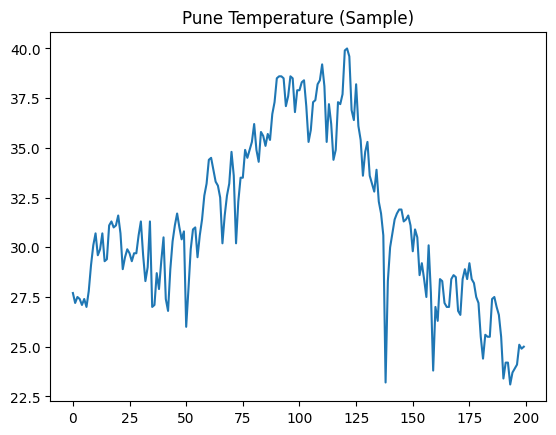

In [ ]:
import matplotlib.pyplot as plt

plt.plot(data[:200])
plt.title("Pune Temperature (Sample)")
plt.show()

In [ ]:
import numpy as np

def create_sequences(data, window):
    X, y = [], []

    for i in range(len(data) - window):
        X.append(data[i : i + window])   # past values
        y.append(data[i + window])       # next value

    return np.array(X), np.array(y)

# choose window size
WINDOW_SIZE = 5

X, y = create_sequences(scaled_data, WINDOW_SIZE)

# check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9127, 5, 1)
y shape: (9127, 1)


In [ ]:
X[0]

array([[0.29953917],
       [0.2764977 ],
       [0.29032258],
       [0.28571429],
       [0.2718894 ]])

In [ ]:
y[0]

array([0.28571429])

In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (7301, 5, 1)
Test size: (1826, 5, 1)


In [ ]:
import torch

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Check
print(type(X_train))
print(X_train.shape)

<class 'torch.Tensor'>
torch.Size([7301, 5, 1])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
X_train = X_train.to(device)
y_train = y_train.to(device)

X_test = X_test.to(device)
y_test = y_test.to(device)

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

batch_size = 32

train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False   # IMPORTANT for time-series
)

In [ ]:
for batch_X, batch_y in train_loader:
    print(batch_X.shape)
    print(batch_y.shape)
    break

torch.Size([32, 5, 1])
torch.Size([32, 1])


In [ ]:
import torch.nn as nn

class WeatherLSTM(nn.Module):
    def __init__(self):
        super(WeatherLSTM, self).__init__()

        self.hidden_size = 64
        self.num_layers = 2

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=self.hidden_size,
            num_layers=self.num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(self.hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = self.fc(out)

        return out

In [ ]:
model = WeatherLSTM()

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model = model.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Using 2 GPUs


In [ ]:
epochs = 50

train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    # 🔹 TRAINING
    for batch_X, batch_y in train_loader:

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(train_loader)
    train_losses.append(train_loss)

    # 🔹 TEST LOSS
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test).item()
        test_losses.append(test_loss)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.5f}, Test Loss: {test_loss:.5f}")

Epoch 1, Train Loss: 0.02737, Test Loss: 0.00568
Epoch 2, Train Loss: 0.00585, Test Loss: 0.00630
Epoch 3, Train Loss: 0.00572, Test Loss: 0.00577
Epoch 4, Train Loss: 0.00532, Test Loss: 0.00518
Epoch 5, Train Loss: 0.00487, Test Loss: 0.00463
Epoch 6, Train Loss: 0.00483, Test Loss: 0.00421
Epoch 7, Train Loss: 0.00484, Test Loss: 0.00502
Epoch 8, Train Loss: 0.00375, Test Loss: 0.00332
Epoch 9, Train Loss: 0.00421, Test Loss: 0.00466
Epoch 10, Train Loss: 0.00314, Test Loss: 0.00294
Epoch 11, Train Loss: 0.00315, Test Loss: 0.00304
Epoch 12, Train Loss: 0.00316, Test Loss: 0.00456
Epoch 13, Train Loss: 0.00315, Test Loss: 0.00289
Epoch 14, Train Loss: 0.00317, Test Loss: 0.00290
Epoch 15, Train Loss: 0.00289, Test Loss: 0.00310
Epoch 16, Train Loss: 0.00298, Test Loss: 0.00323
Epoch 17, Train Loss: 0.00296, Test Loss: 0.00403
Epoch 18, Train Loss: 0.00301, Test Loss: 0.00294
Epoch 19, Train Loss: 0.00288, Test Loss: 0.00314
Epoch 20, Train Loss: 0.00296, Test Loss: 0.00323
Epoch 21,

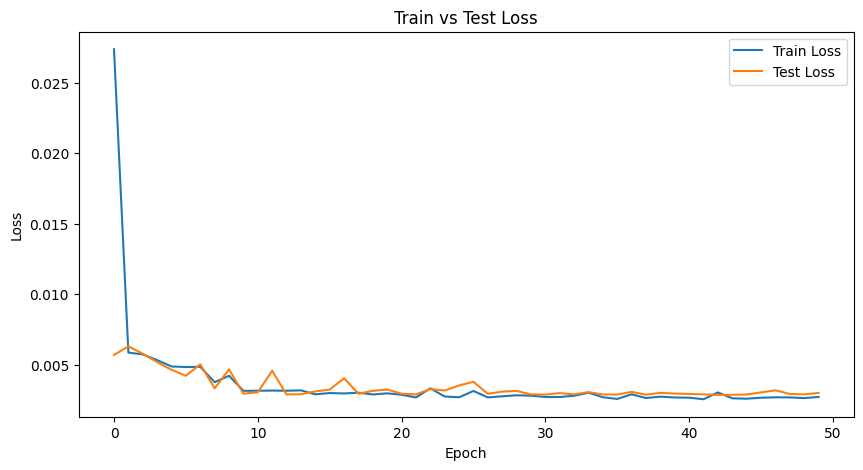

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.title("Train vs Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    test_loss = criterion(test_outputs, y_test)

print(f"Epoch {epoch+1}, Train Loss: {epoch_loss/len(train_loader):.5f}, Test Loss: {test_loss.item():.5f}")

Epoch 50, Train Loss: 0.00271, Test Loss: 0.00299


In [ ]:
predictions = scaler.inverse_transform(predictions)
actuals = scaler.inverse_transform(actuals)

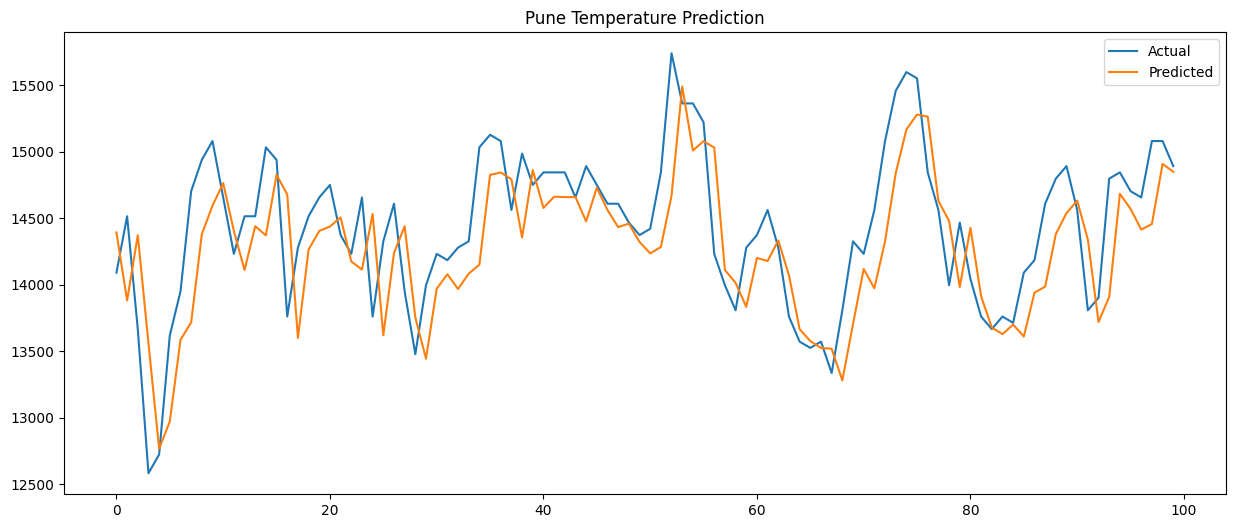

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(actuals[-100:], label='Actual')
plt.plot(predictions[-100:], label='Predicted')

plt.title("Pune Temperature Prediction")
plt.legend()
plt.show()

In [ ]:
last_5_days = scaled_data[-5:].reshape(1, 5, 1)
last_5_days = torch.tensor(last_5_days, dtype=torch.float32).to(device)

with torch.no_grad():
    future_pred = model(last_5_days).cpu().numpy()

future_temp = scaler.inverse_transform(future_pred)

print(f"Next day temperature: {future_temp[0][0]:.2f}°C")

Next day temperature: 30.67°C


In [ ]:
torch.save(model.module.state_dict(), "pune_model.pth")

import joblib
joblib.dump(scaler, "pune_scaler.save")

['pune_scaler.save']

# 🔥 PyTorch Usage Summary

In this notebook, we used PyTorch to build and train an LSTM-based time-series model for temperature prediction. The implementation covers the complete pipeline from data handling to model training and inference using core PyTorch components:

- **Tensors (`torch.tensor`)** → used to convert NumPy data into PyTorch format for computation  
- **Device management (`.to(device)`)** → used to move data and model to GPU/CPU for efficient processing  
- **Model definition (`nn.Module`)** → used to create a custom LSTM-based neural network  
- **LSTM layer (`nn.LSTM`)** → used to process sequential temperature data and capture temporal dependencies  
- **Fully connected layer (`nn.Linear`)** → used to map LSTM output to final temperature prediction  
- **Loss function (`nn.MSELoss`)** → used to measure prediction error for regression  
- **Optimizer (`torch.optim.Adam`)** → used to update model weights during training  
- **Autograd (`loss.backward()`)** → used for automatic gradient computation during backpropagation  
- **Data handling (`TensorDataset`, `DataLoader`)** → used to create batches and efficiently feed data into the model  
- **Training mode (`model.train()`)** → enables training behavior during learning  
- **Evaluation mode (`model.eval()`)** → used during testing and inference  
- **No gradient context (`torch.no_grad()`)** → disables gradient computation for faster inference  
- **Forward pass (`model(batch_X)`)** → used to generate predictions from input sequences  
- **Model saving (`torch.save`)** → used to store trained model weights for deployment  

Overall, PyTorch enabled efficient tensor computation, automatic differentiation, modular model design, and seamless training of a sequence-based neural network.